In [1]:
from datasets import load_dataset, concatenate_datasets,Dataset
from glob import glob
from collections import Counter

import os
import json

/opt/conda/envs/sppo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt

set_task_category = {'Advice seeking',
 'Brainstorming',
 'Creative writing',
 'Data analysis',
 'Editing',
 'Information seeking',
 'Planning',
 'Reasoning',
 'Role playing',
 'Coding & Debugging',
 'Math',
 }

def preprocess_task(example):
    if example["task_category"] not in set_task_category:
        example["task_category"] = "Other"
    return example

In [6]:
ds = load_dataset("slm-research-vn/slm-instruct-v0.1-tagged", split="train")

ds = ds.map(preprocess_task)

Map: 100%|██████████| 373941/373941 [01:02<00:00, 5942.92 examples/s]


In [ ]:
task_category_counter = Counter(ds["task_category"])
task_category_counter

# pie chart
# fig size
plt.figure(figsize=(20, 20))
plt.pie(task_category_counter.values(), labels=task_category_counter.keys(), autopct='%1.1f%%')

<BarContainer object of 2 artists>

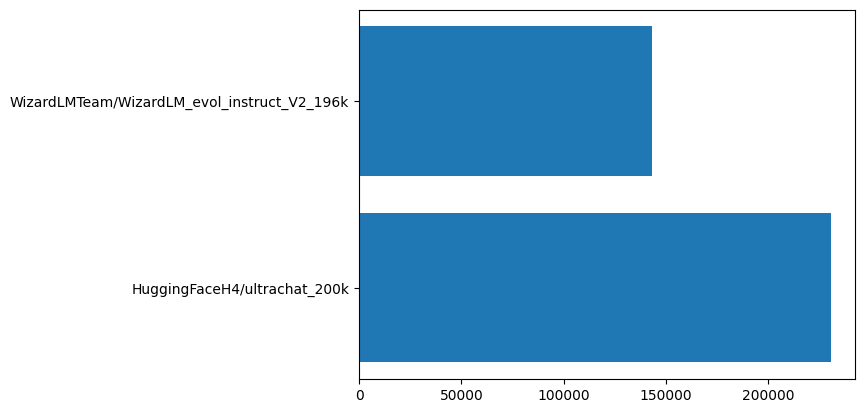

In [10]:
source_counter = Counter(ds["source"])

# horizontal bar chart
# plt.figure(figsize=(20, 20))

plt.barh(list(source_counter.keys()), list(source_counter.values()))

In [3]:
ds_filtered = load_dataset("slm-research-vn/slm-instruct-v0.1-filtered", split="train")

ds_filtered = ds_filtered.map(preprocess_task)

Map: 100%|██████████| 115019/115019 [00:20<00:00, 5634.95 examples/s]


In [ ]:
task_category_counter = Counter(ds_filtered["task_category"])

# pie chart
# fig size
plt.figure(figsize=(20, 20))
plt.pie(task_category_counter.values(), labels=task_category_counter.keys(), autopct='%1.1f%%')